In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import so

## Load the data

In [7]:
df = so.load_data()
so.did_prepare_data(df)
print(df.info())
    
questions = so.questions(df)
answers = so.answers(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5997763 entries, 0 to 5997762
Data columns (total 20 columns):
 #   Column            Dtype         
---  ------            -----         
 0   PostTypeId        int64         
 1   AcceptedAnswerId  float64       
 2   CreationDate      datetime64[ns]
 3   Score             int64         
 4   ViewCount         float64       
 5   AnswerCount       float64       
 6   CommentCount      int64         
 7   FavoriteCount     float64       
 8   OwnerUserId       float64       
 9   Title             object        
 10  Tags              object        
 11  line_count        float64       
 12  T                 int64         
 13  P                 int64         
 14  W                 int64         
 15  code              object        
 16  text              object        
 17  log_lc            float64       
 18  D                 int32         
 19  date              datetime64[ns]
dtypes: datetime64[ns](2), float64(7), int32(1), in

In [9]:
# Tags
filenames = ['java_c.csv', 'python_c.csv', 'web_c.csv']
tags = ['java', 'python', 'web']

tag_dfs = {}
for tag, filename in zip(tags, filenames):
        print(f'Loading: {tag}')
        tag_df = so.load_data(f'data/csv/tags/{filename}')
        so.did_prepare_data(tag_df, 'tags')
        tag_dfs[tag] = tag_df

Loading: java
Loading: python
Loading: web


## Util functions

In [10]:
def clean(data):
    data = data.dropna(subset=['OwnerUserId']).copy()
    data['OwnerUserId'] = data['OwnerUserId'].astype(int)
    return data

In [11]:
def users():
    users = pd.read_csv('data/csv/users/users.csv')
    return users

In [12]:
def join(data, users):
    posts_users = data.merge(users, how='inner', left_on='OwnerUserId', right_on='Id')
    return posts_users

In [13]:
def freq_dist(data):
    counts = data.groupby('OwnerUserId').size()
    counts_sorted = counts.sort_values(ascending=False)
    print(counts_sorted)

    freq = counts.value_counts(sort=False)
    sns.barplot(x=freq.index, y=freq.values, errorbar=None)
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('Number of posts')
    plt.ylabel('Number of users')
    plt.title('Posting frequency distribution')
    plt.show()

    return counts

In [14]:
def groups(data, counts):
    oneoff = counts[counts == 1]
    #sporadic = counts[(counts > 1) & (counts <= 10)]
    #regular =  counts[(counts > 10) & (counts <= 50)]
    #power = counts[counts > 50]

    rest = counts[counts > 1]
    rest_sorted = rest.sort_values(kind="mergesort")  # stable sort
    vals = rest_sorted.to_numpy()
    cum = np.cumsum(vals)
    total = cum[-1]
    cut1 = np.searchsorted(cum, total / 4, side='left')
    cut2 = np.searchsorted(cum, 3 * total / 4, side='left')
    sporadic = rest_sorted.iloc[:cut1]
    regular =  rest_sorted.iloc[cut1:cut2]
    power = rest_sorted.iloc[cut2:]

    oneoff_users = oneoff.index
    sporadic_users = sporadic.index
    regular_users = regular.index
    power_users = power.index

    oneoff_events = data[data['OwnerUserId'].isin(oneoff_users)]
    sporadic_events = data[data['OwnerUserId'].isin(sporadic_users)]
    regular_events = data[data['OwnerUserId'].isin(regular_users)]
    power_events = data[data['OwnerUserId'].isin(power_users)]

    return oneoff_events, sporadic_events, regular_events, power_events

In [15]:
def regression(data, outcome):
    start_dates, masks = so.rolling_window_masks(data, data_column='date', normalized=True, window_days=30)    

    X, y = so.did_design_matrix(f'{outcome}_bar', data)
    res = so.did_wls(data, X, y, masks, start_dates, outcome)
    return res

In [16]:
users_df = users()

Processing: questions
OwnerUserId
23512643.0    727
2628868.0     632
651174.0      455
847881.0      418
5432156.0     382
             ... 
414.0           1
366.0           1
363.0           1
9976732.0       1
20420660.0      1
Length: 1102384, dtype: int64


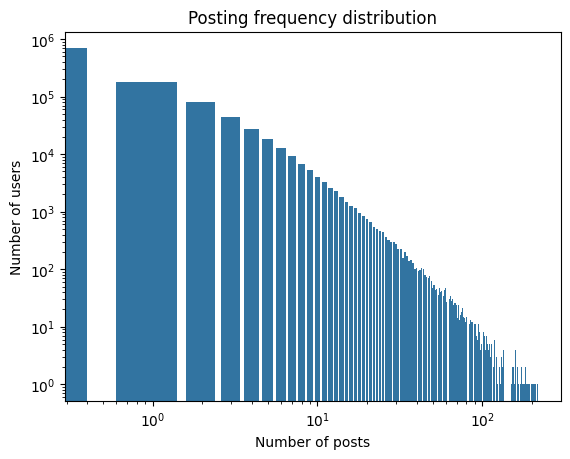

690995 477502 955003 477510
OwnerUserId
22570253.0    1
29.0          1
33.0          1
21976270.0    1
21976260.0    1
             ..
188.0         1
113.0         1
101.0         1
85.0          1
51.0          1
Length: 690995, dtype: int64
Processing: log_lc


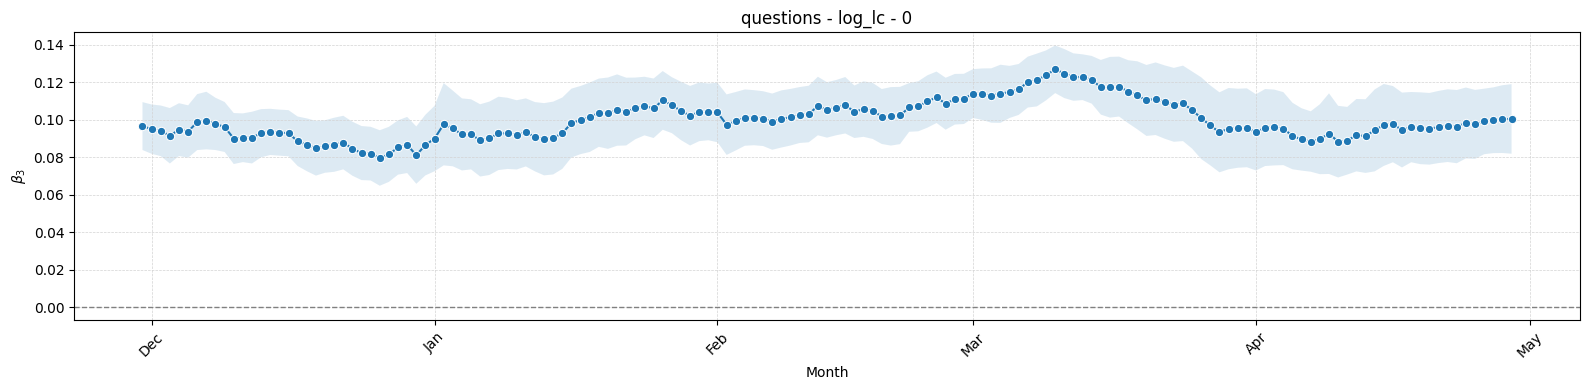

OwnerUserId
232.0        3
3750890.0    3
260.0        3
6668554.0    3
6668589.0    3
            ..
781405.0     2
1431.0       2
1450.0       2
781421.0     2
203.0        2
Length: 218957, dtype: int64
Processing: log_lc


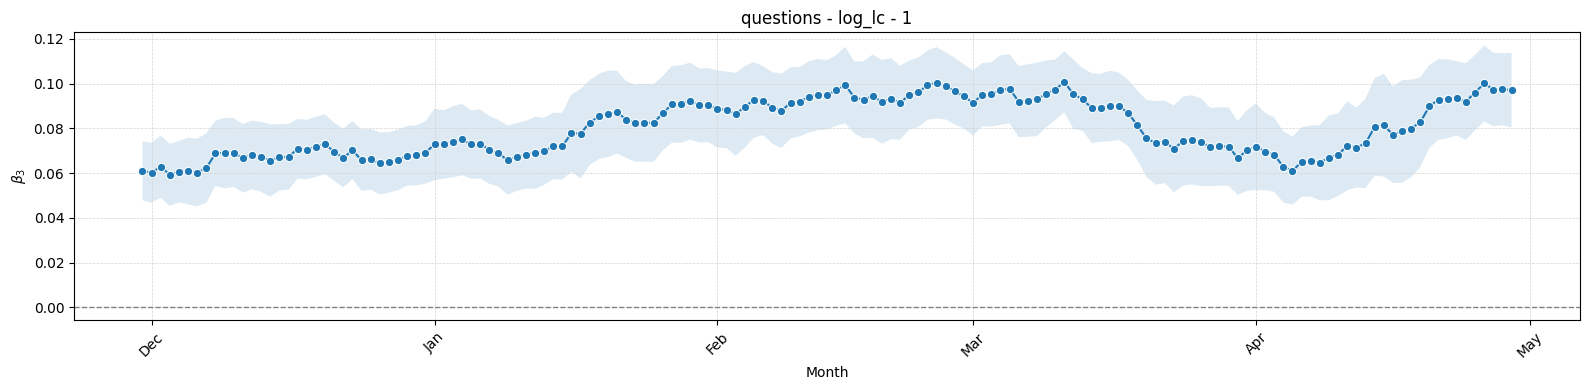

OwnerUserId
1706692.0     14
9330780.0     14
9324203.0     14
1725974.0     14
1728856.0     14
              ..
17960758.0     3
17960699.0     3
17960688.0     3
17960057.0     3
17959404.0     3
Length: 175182, dtype: int64
Processing: log_lc


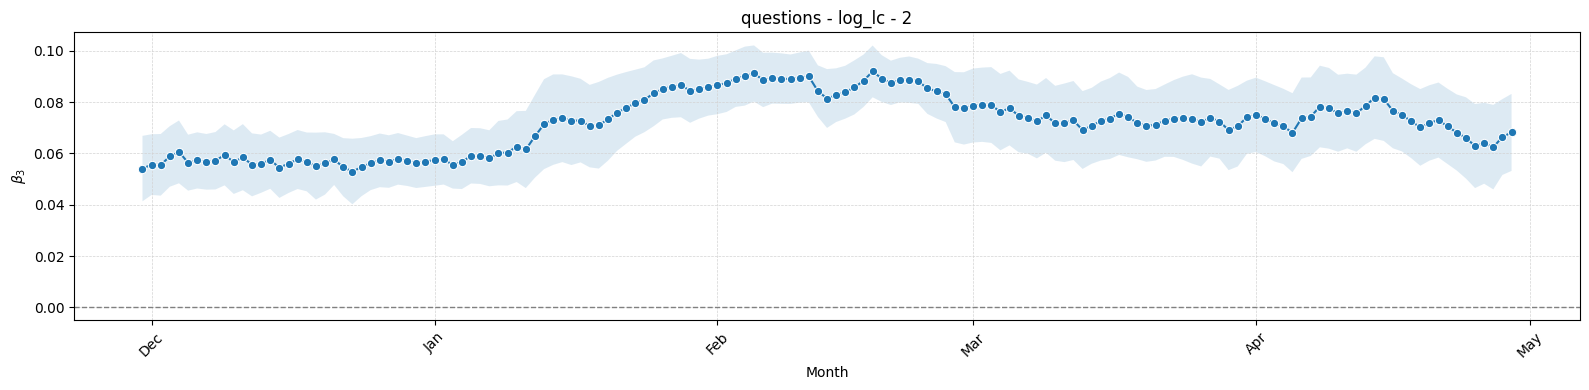

OwnerUserId
23512643.0    727
2628868.0     632
651174.0      455
847881.0      418
5432156.0     382
             ... 
16928115.0     14
16929147.0     14
16951437.0     14
16958095.0     14
16958886.0     14
Length: 17250, dtype: int64
Processing: log_lc


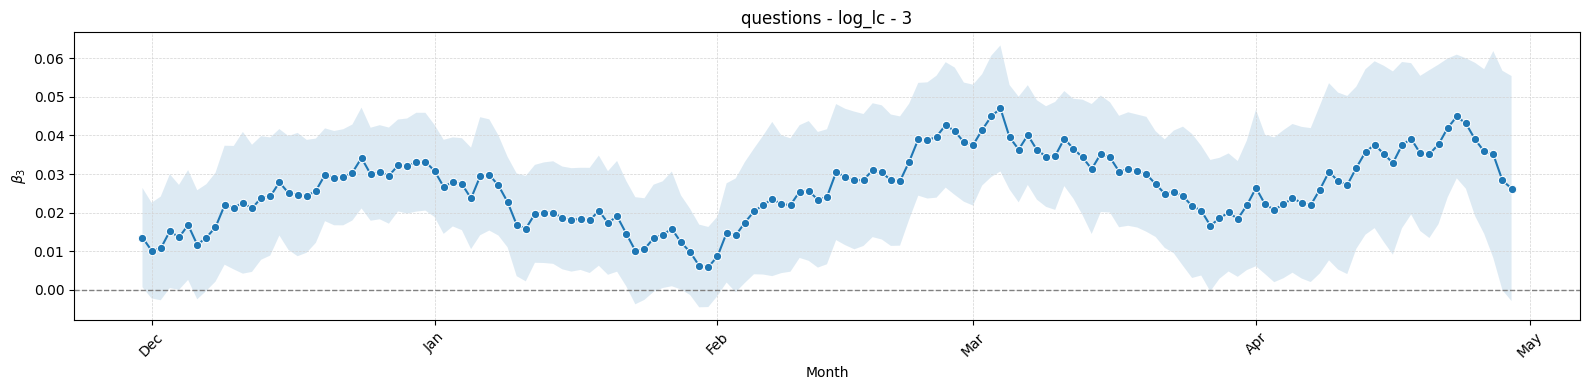

Processing: answers
OwnerUserId
16343464.0    9808
3732271.0     7992
2901002.0     5525
1491895.0     5487
15239951.0    4975
              ... 
21975812.0       1
21975823.0       1
21975969.0       1
21975990.0       1
21976126.0       1
Length: 742193, dtype: int64


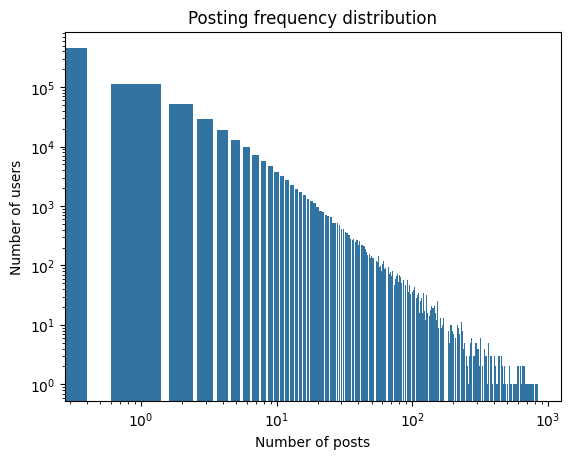

449584 718385 1436552 718606
OwnerUserId
21975785.0    1
21975714.0    1
21975629.0    1
21975625.0    1
21975619.0    1
             ..
61.0          1
56.0          1
49.0          1
35.0          1
29.0          1
Length: 449584, dtype: int64
Processing: log_lc


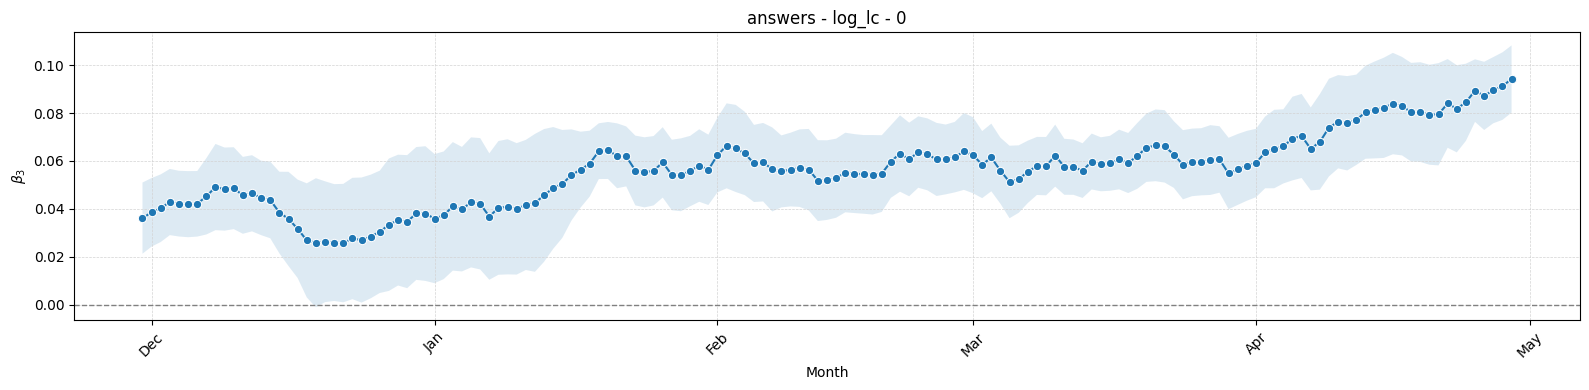

OwnerUserId
1197577.0     7
11127623.0    7
11127438.0    7
11129093.0    7
1201244.0     7
             ..
21963969.0    2
432.0         2
361.0         2
358.0         2
338.0         2
Length: 232940, dtype: int64
Processing: log_lc


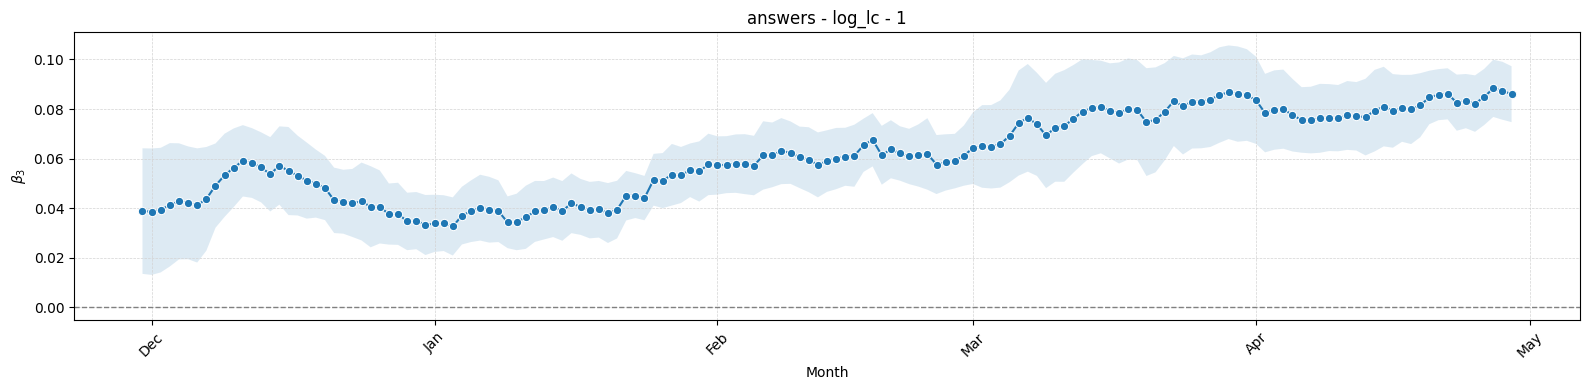

OwnerUserId
1322268.0     271
207090.0      271
7281675.0     271
225020.0      271
2358409.0     271
             ... 
21770975.0      7
21919116.0      7
21765364.0      7
21763379.0      7
14418422.0      7
Length: 58621, dtype: int64
Processing: log_lc


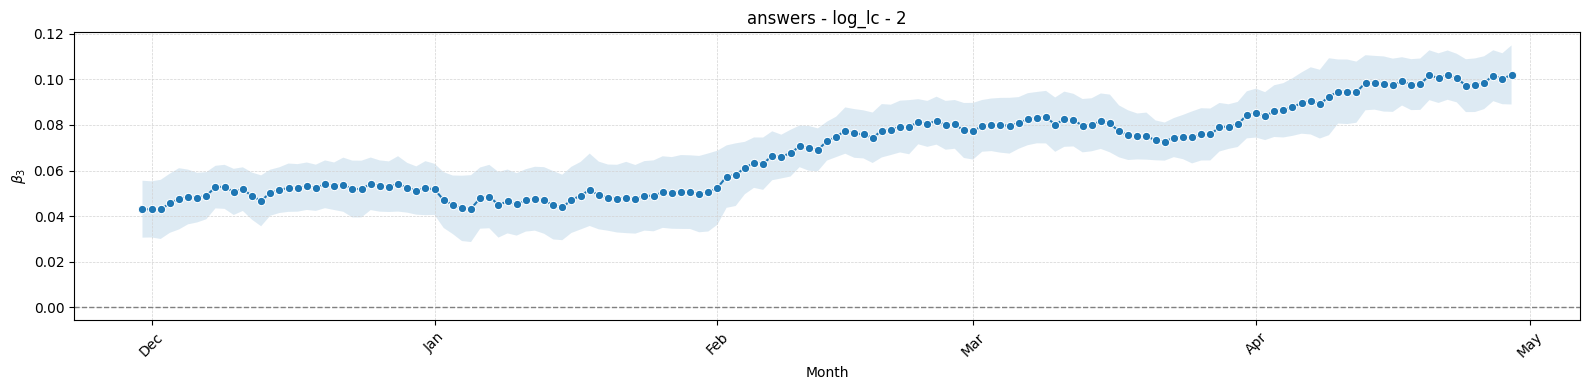

OwnerUserId
16343464.0    9808
3732271.0     7992
2901002.0     5525
1491895.0     5487
15239951.0    4975
              ... 
10147399.0     273
16452840.0     273
4433386.0      273
12258459.0     272
1820446.0      272
Length: 1048, dtype: int64
Processing: log_lc


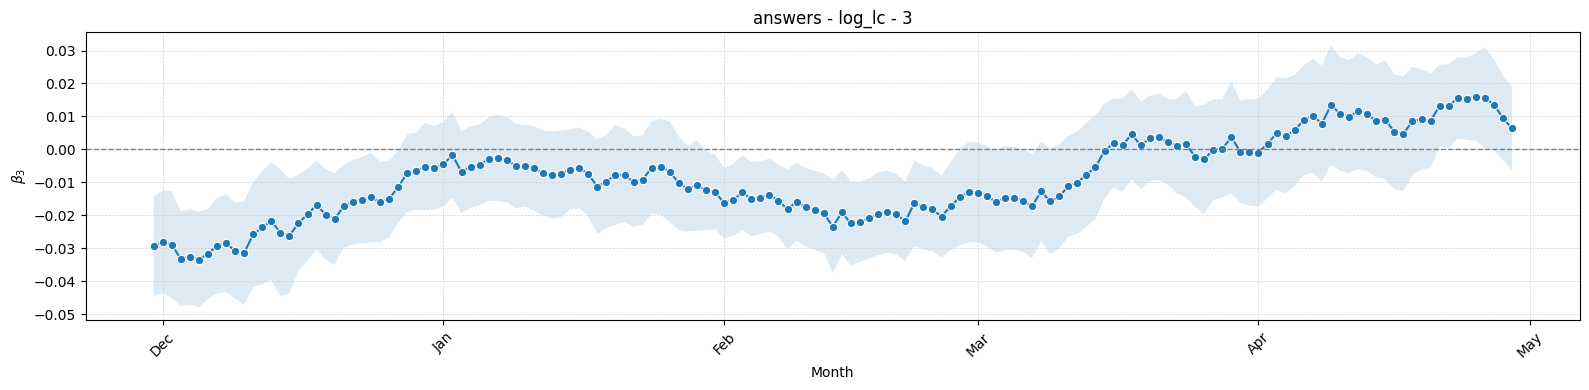

Processing: java
OwnerUserId
836018.0      143
5719229.0     128
1103606.0     115
10461625.0    114
2628868.0      93
             ... 
21972043.0      1
1322.0          1
1023.0          1
797.0           1
755.0           1
Length: 82732, dtype: int64


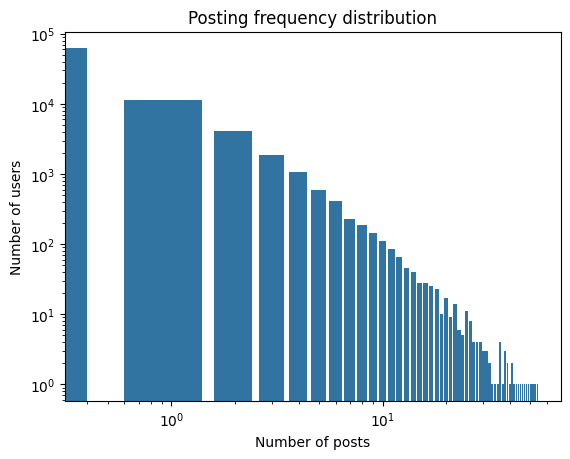

62100 17440 34875 17446
OwnerUserId
21976194.0    1
85.0          1
518.0         1
700.0         1
21970833.0    1
             ..
1712.0        1
1454.0        1
1322.0        1
1023.0        1
797.0         1
Length: 62100, dtype: int64
Processing: log_lc


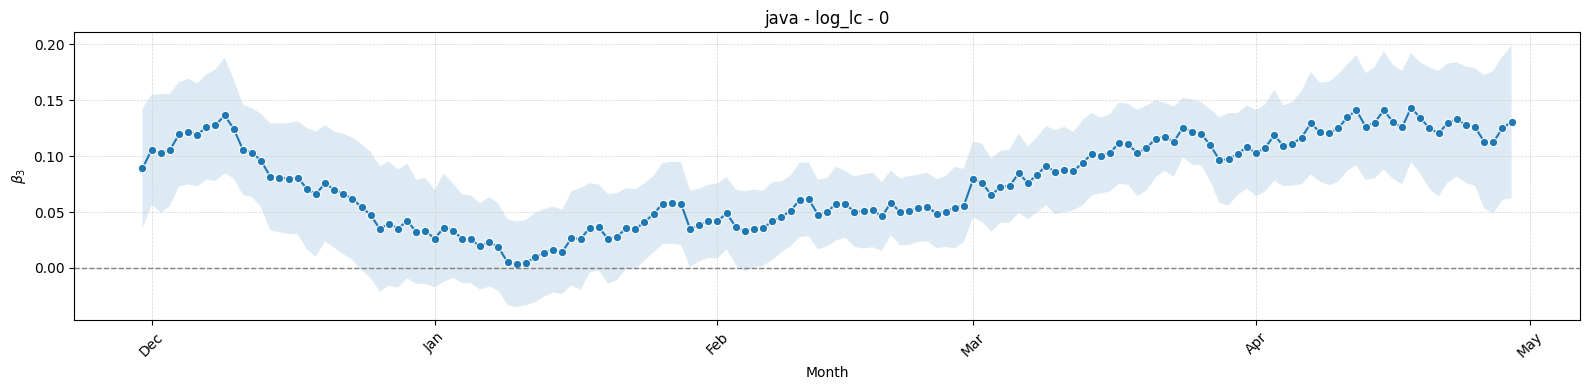

Processing: log_loc


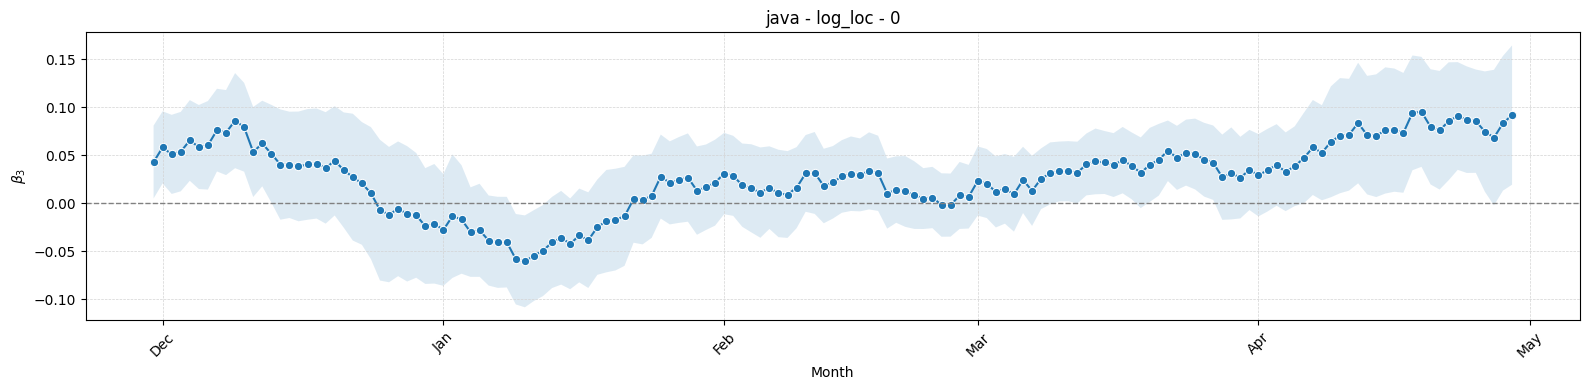

Processing: Medium


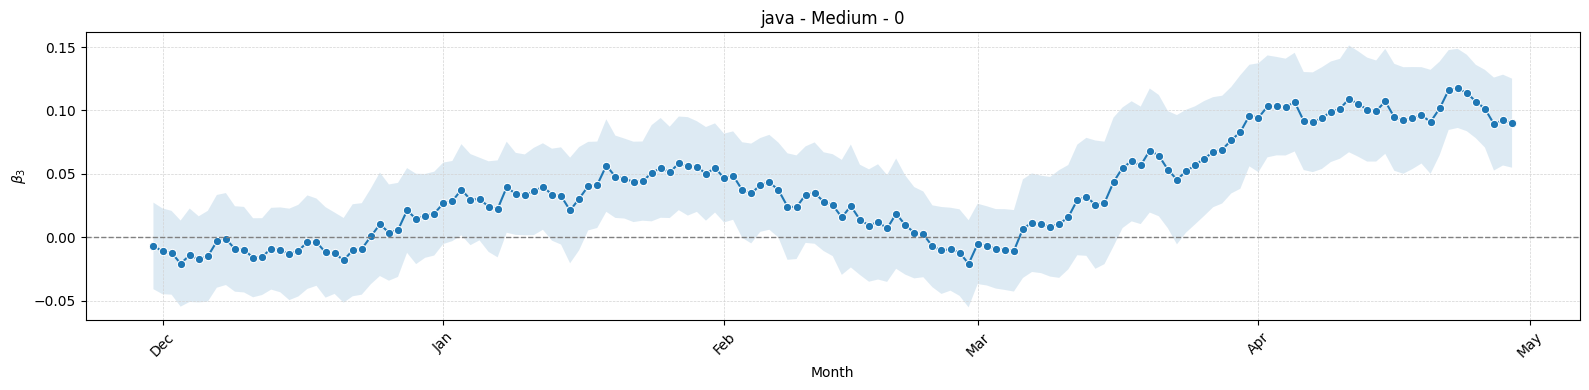

OwnerUserId
17368831.0    2
17368003.0    2
17367929.0    2
17366301.0    2
17365527.0    2
             ..
8482.0        2
4931.0        2
3571.0        2
959.0         2
234.0         2
Length: 8720, dtype: int64
Processing: log_lc


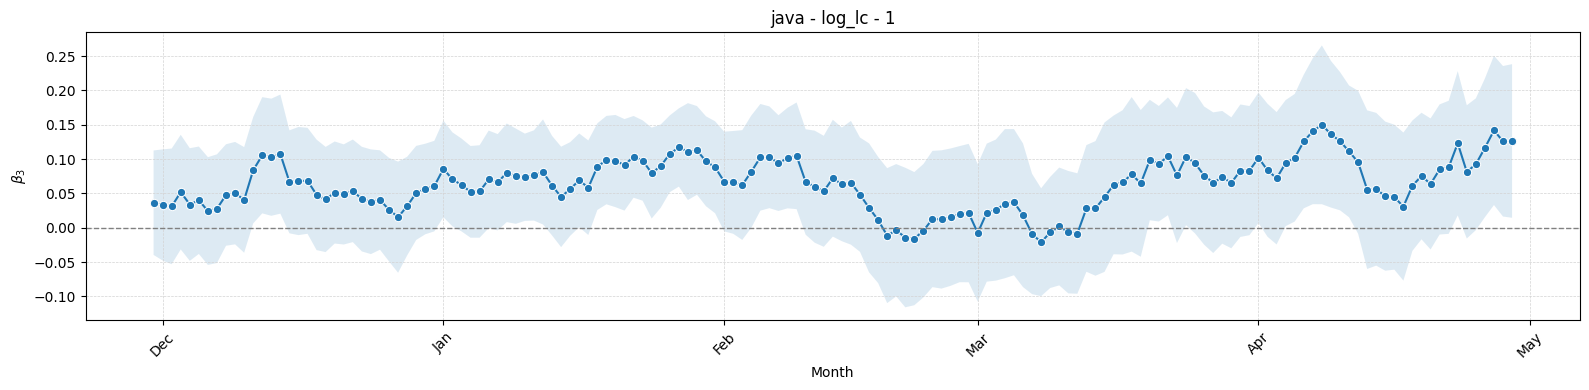

Processing: log_loc


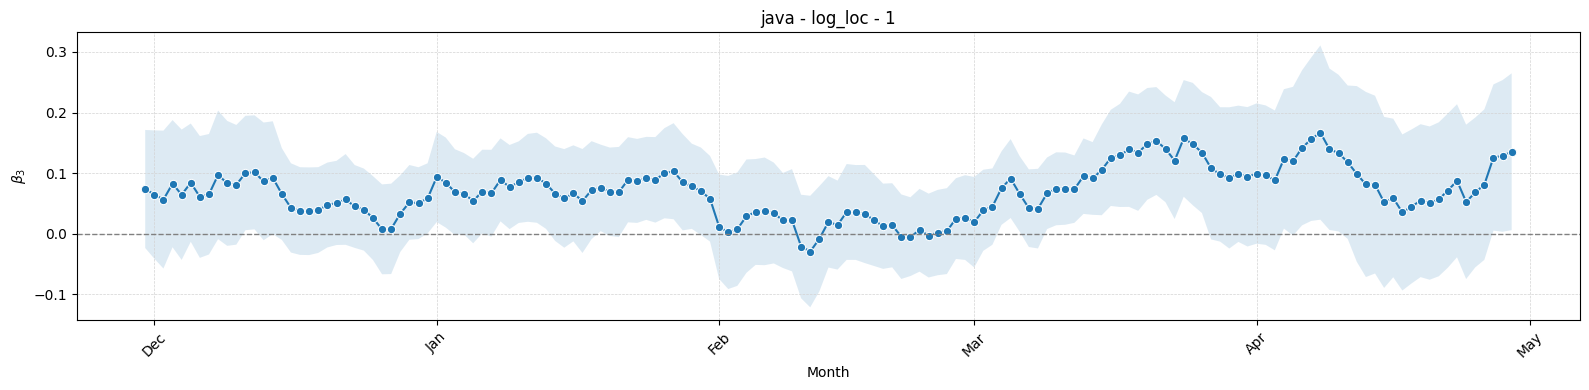

Processing: Medium


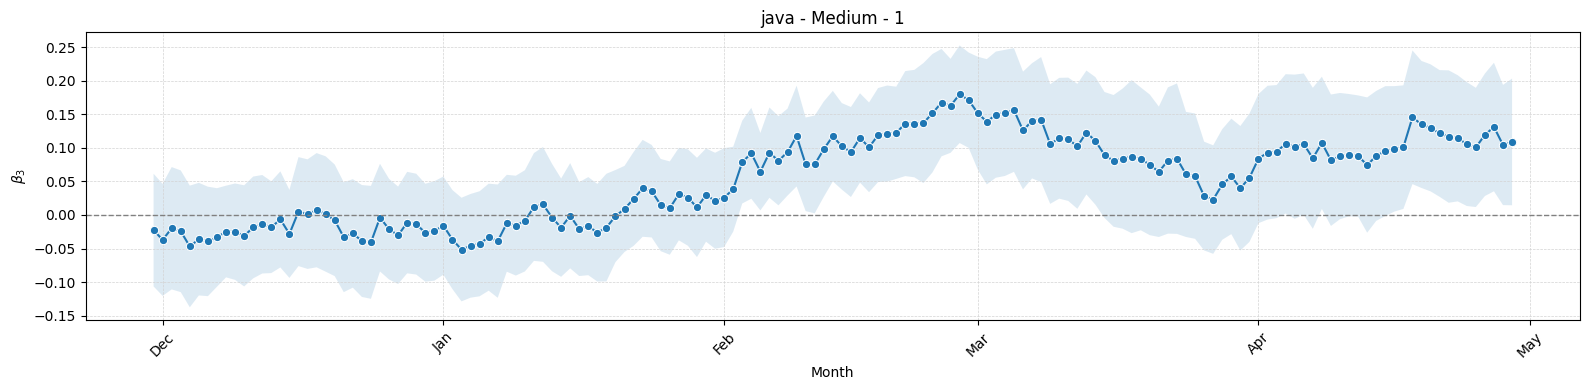

OwnerUserId
474323.0      7
843075.0      7
893254.0      7
765076.0      7
504807.0      7
             ..
21899232.0    2
21881134.0    2
21872757.0    2
21855921.0    2
21853369.0    2
Length: 10461, dtype: int64
Processing: log_lc


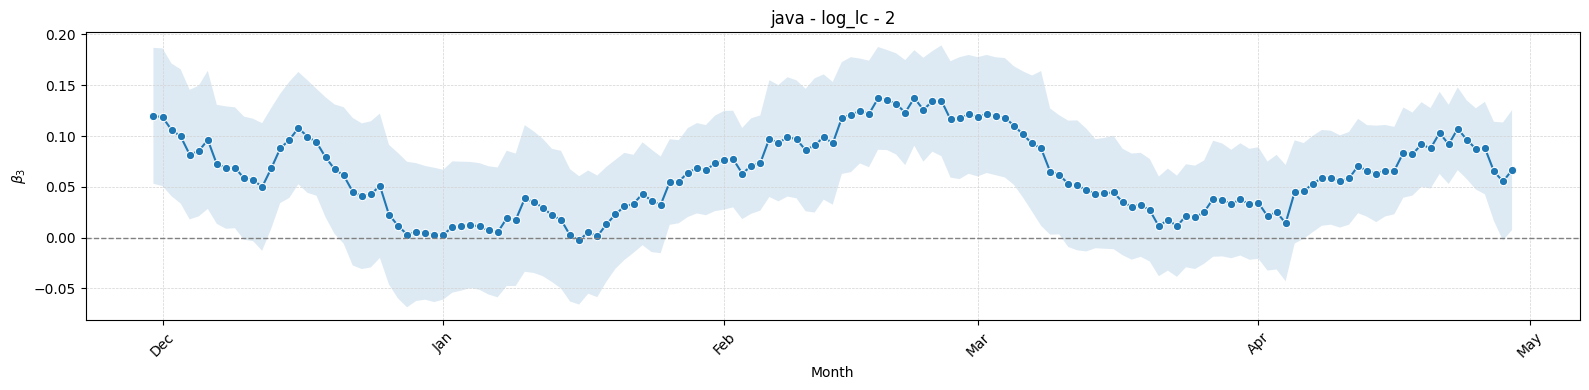

Processing: log_loc


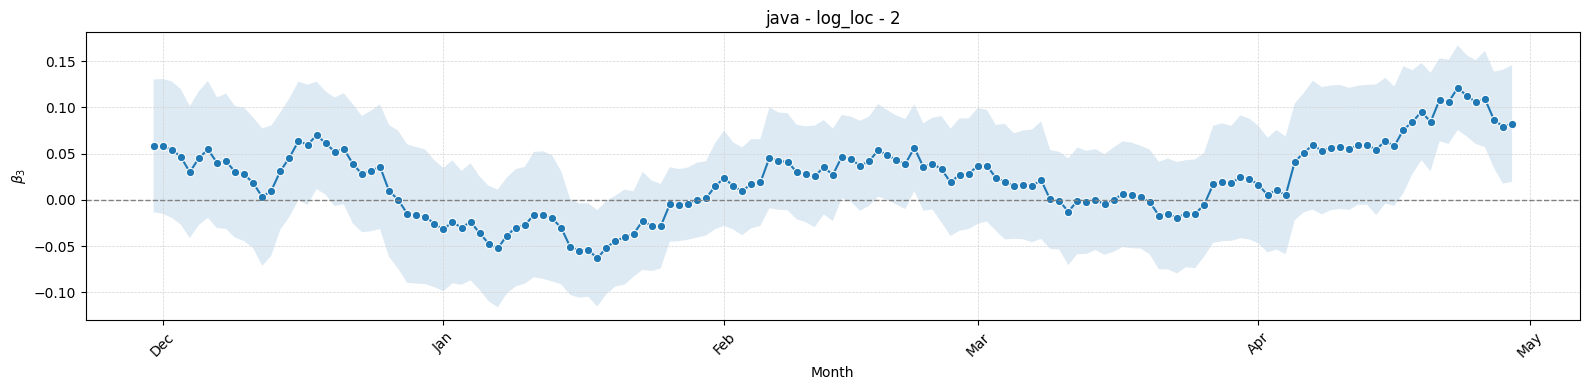

Processing: Medium


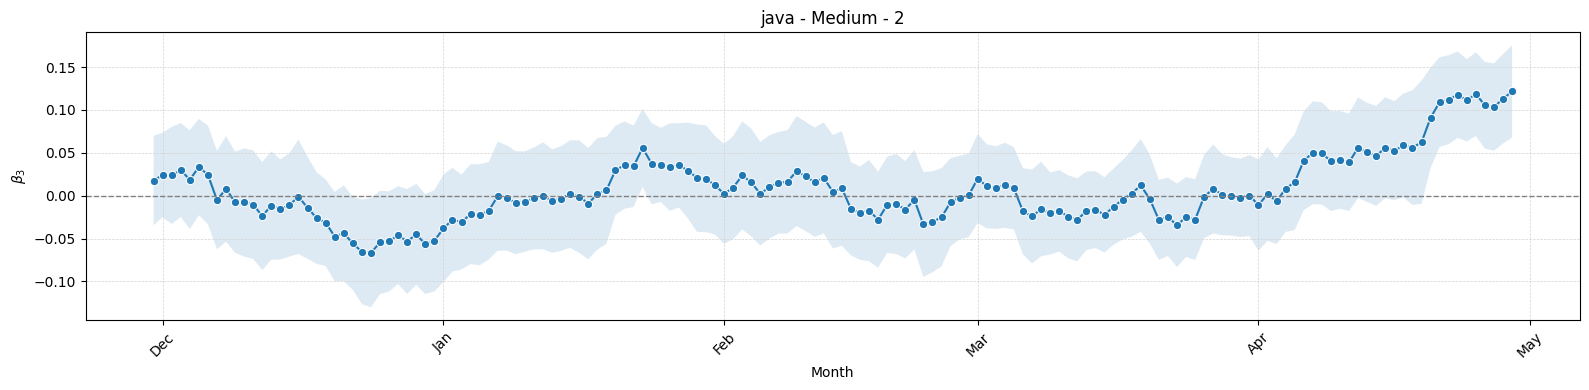

OwnerUserId
836018.0      143
5719229.0     128
1103606.0     115
10461625.0    114
2628868.0      93
             ... 
20080481.0      7
20114912.0      7
20134306.0      7
20160624.0      7
20317930.0      7
Length: 1451, dtype: int64
Processing: log_lc


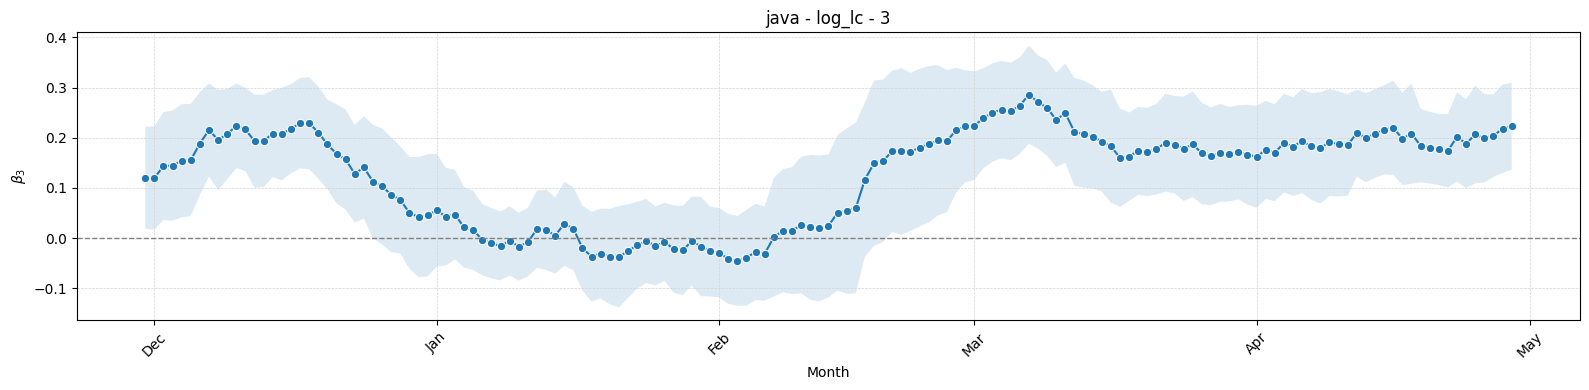

Processing: log_loc


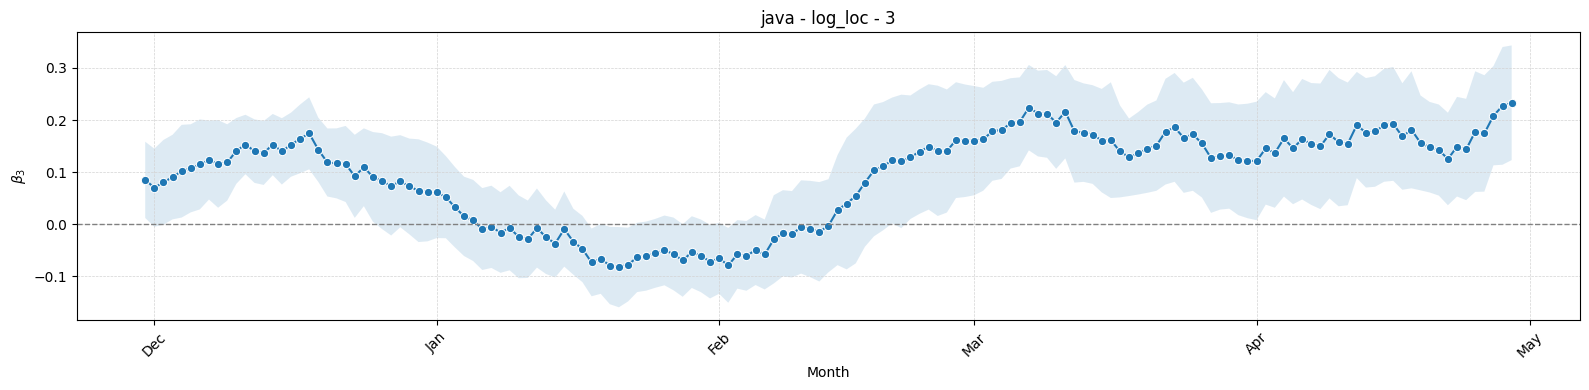

Processing: Medium


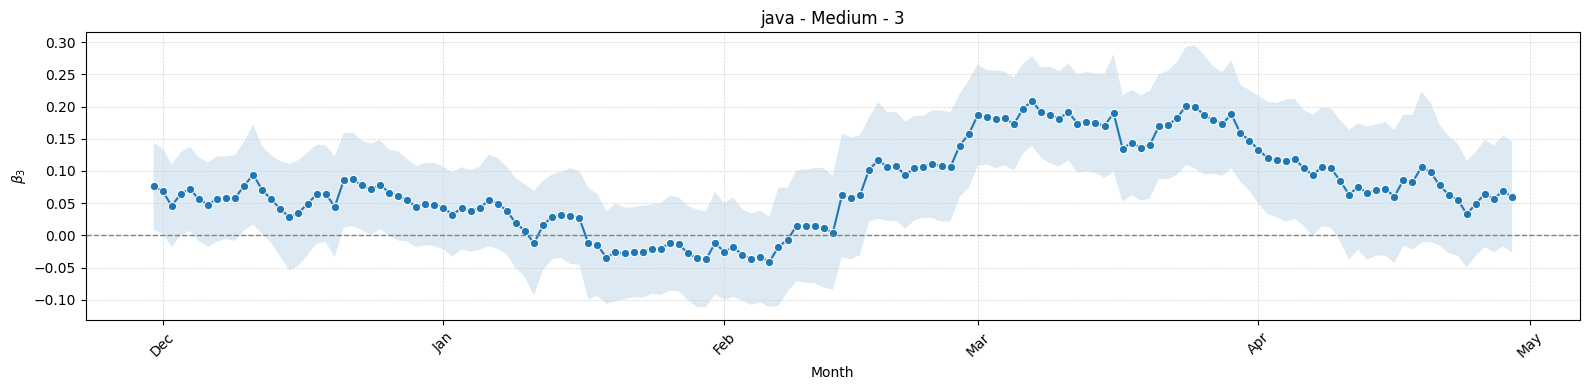

Processing: python
OwnerUserId
10829044.0    223
3380902.0     202
5942100.0     197
3943868.0     150
11462274.0    137
             ... 
3105.0          1
3044.0          1
2312.0          1
2246.0          1
2097.0          1
Length: 238533, dtype: int64


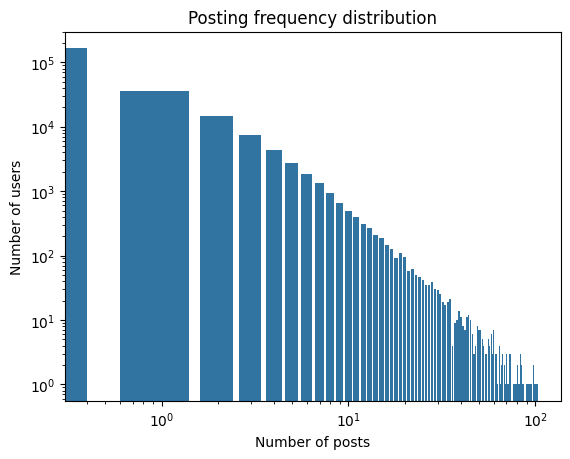

165271 71580 143159 71582
OwnerUserId
22362250.0    1
56.0          1
147.0         1
199.0         1
260.0         1
             ..
2312.0        1
2246.0        1
2097.0        1
1968.0        1
1469.0        1
Length: 165271, dtype: int64
Processing: log_lc


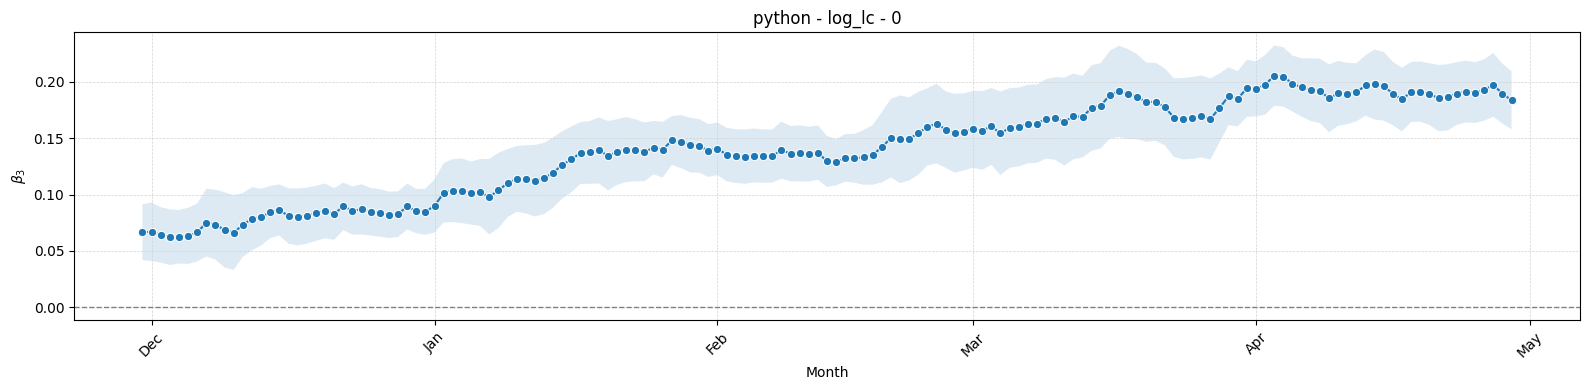

Processing: log_loc


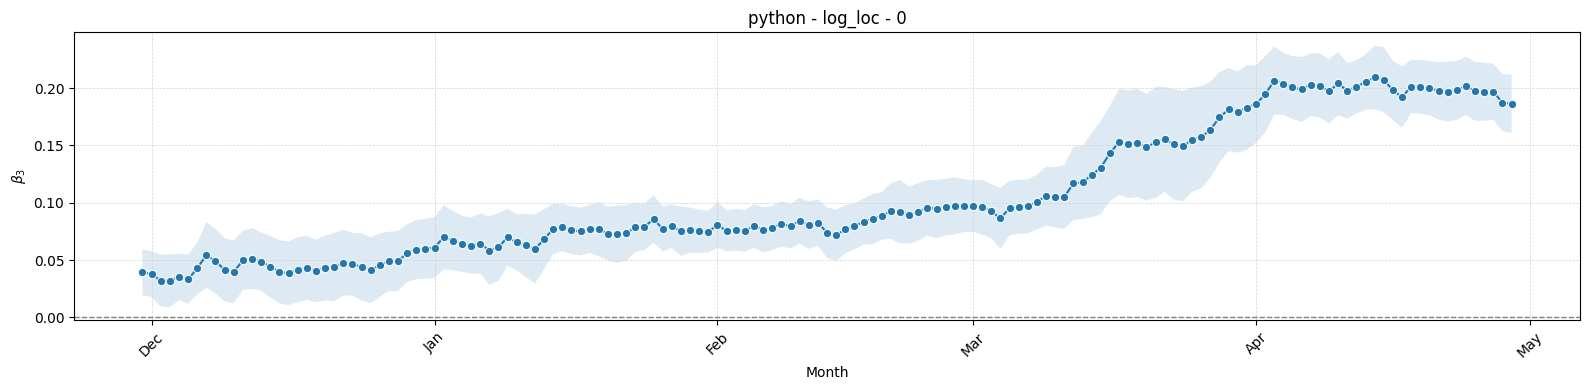

Processing: Medium


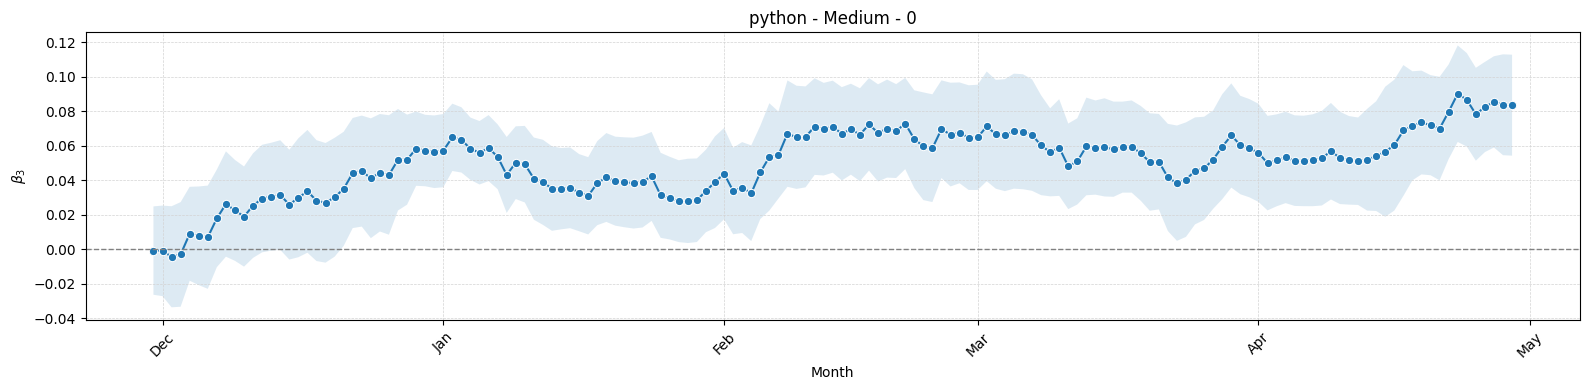

OwnerUserId
21467424.0    2
95.0          2
476.0         2
1912.0        2
3561.0        2
             ..
25891.0       2
21115.0       2
20520.0       2
19816.0       2
18243.0       2
Length: 35790, dtype: int64
Processing: log_lc


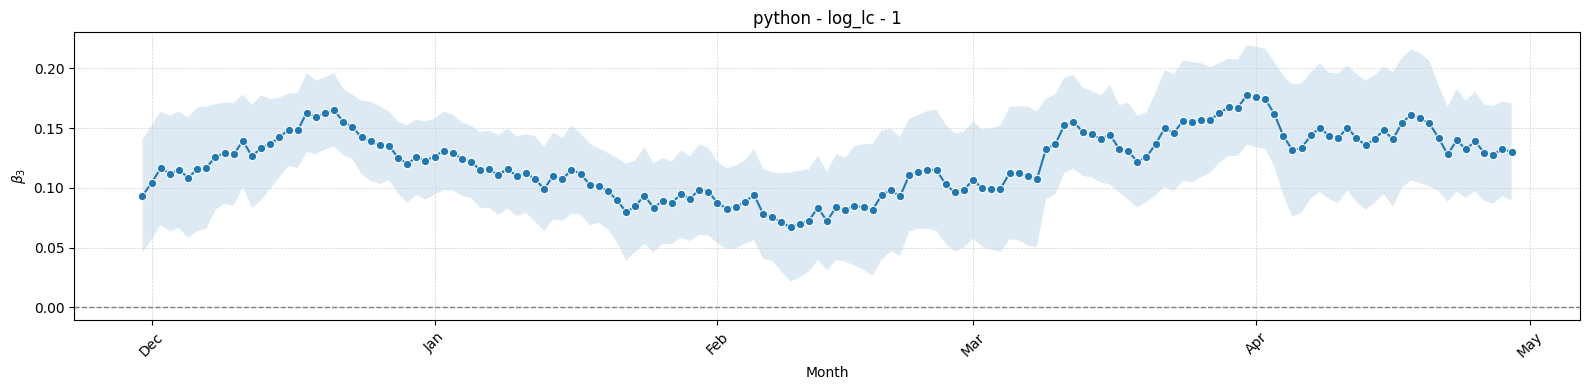

Processing: log_loc


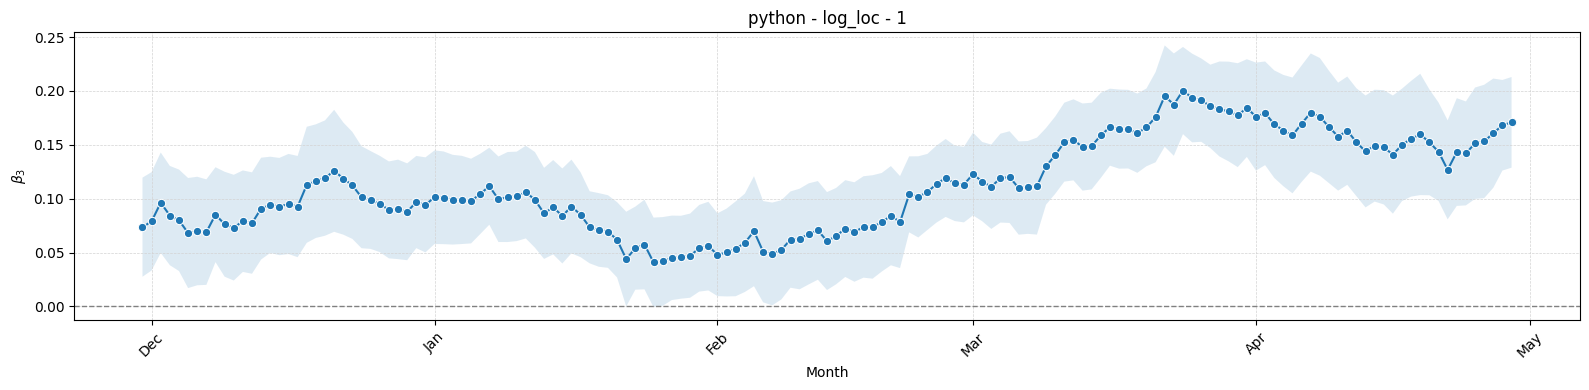

Processing: Medium


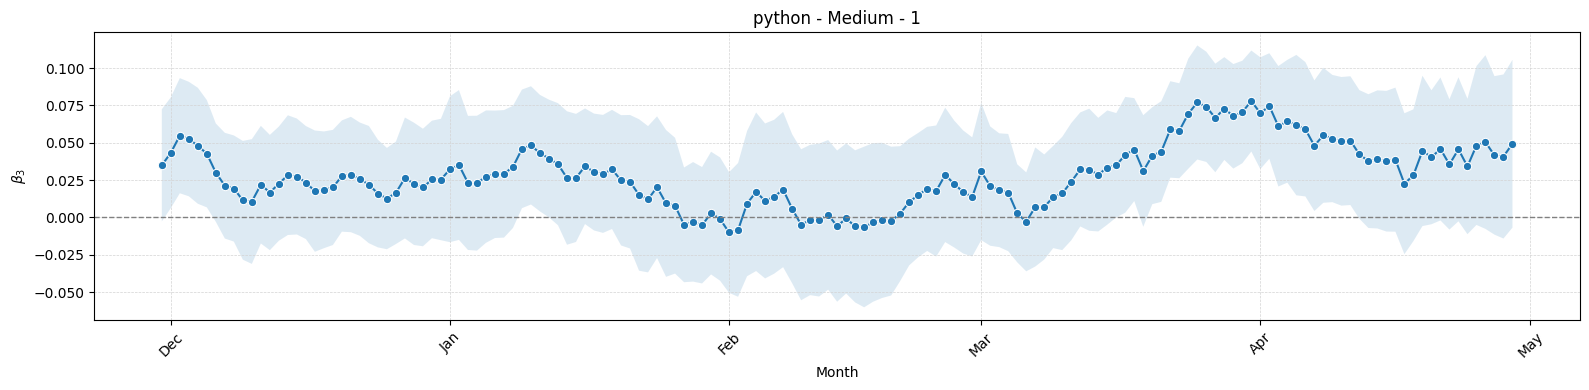

OwnerUserId
92153.0       9
4971866.0     9
12425004.0    9
169947.0      9
8519380.0     9
             ..
21964092.0    2
21962190.0    2
21958052.0    2
21955023.0    2
21946767.0    2
Length: 33457, dtype: int64
Processing: log_lc


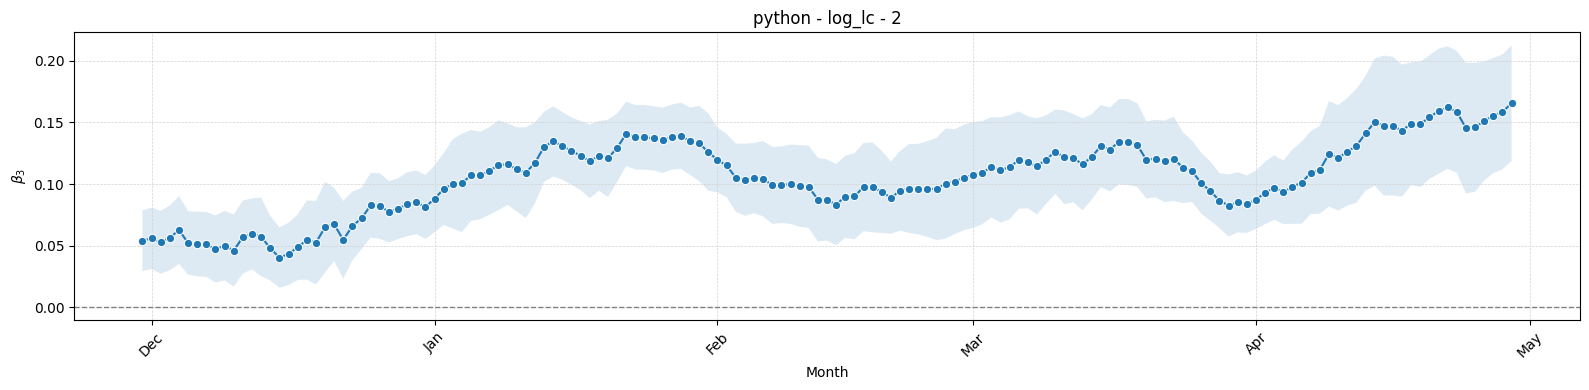

Processing: log_loc


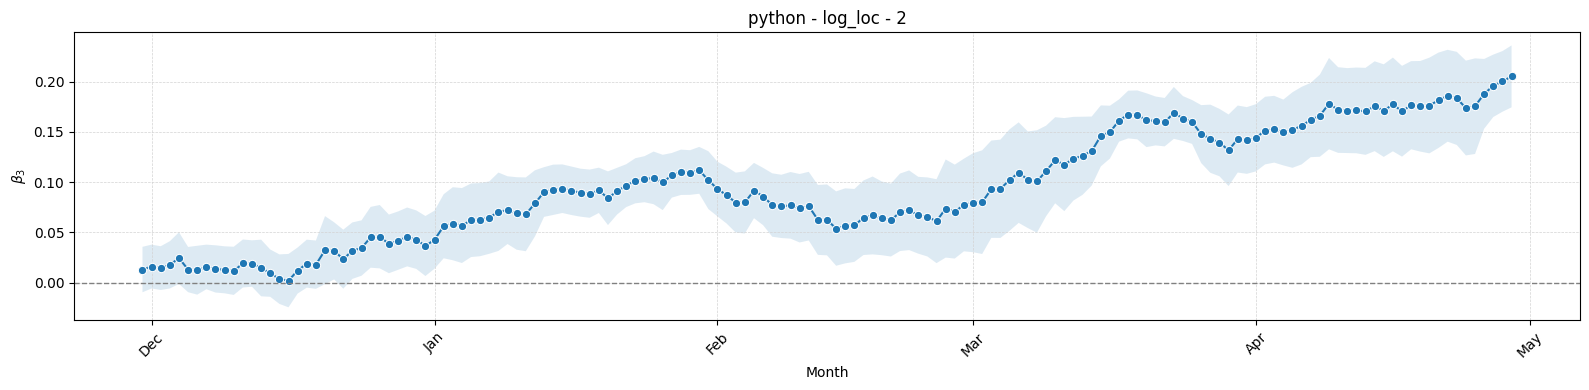

Processing: Medium


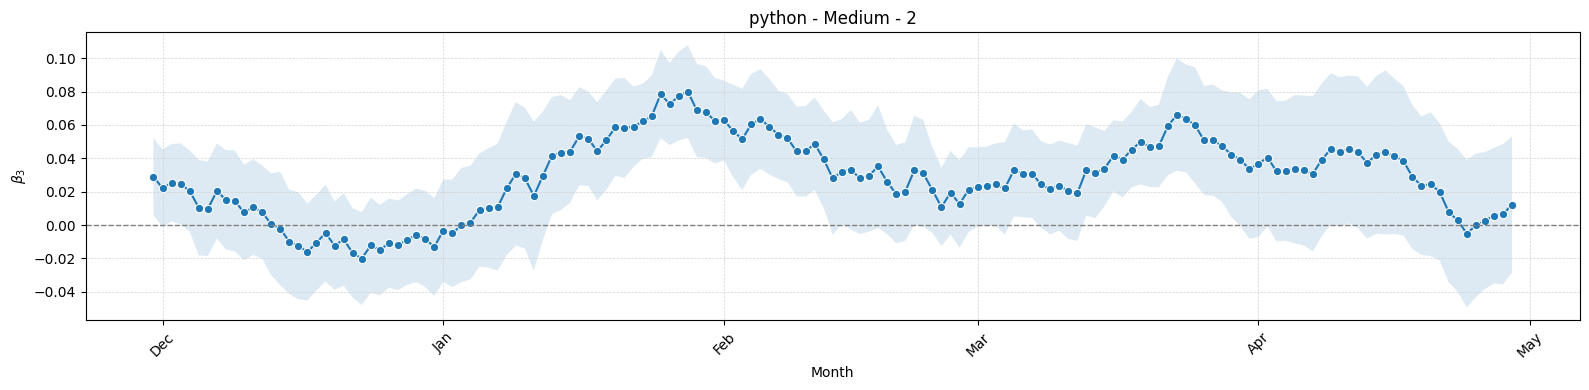

OwnerUserId
10829044.0    223
3380902.0     202
5942100.0     197
3943868.0     150
11462274.0    137
             ... 
21113637.0      9
20874591.0      9
20882139.0      9
21108694.0      9
21787377.0      9
Length: 4015, dtype: int64
Processing: log_lc


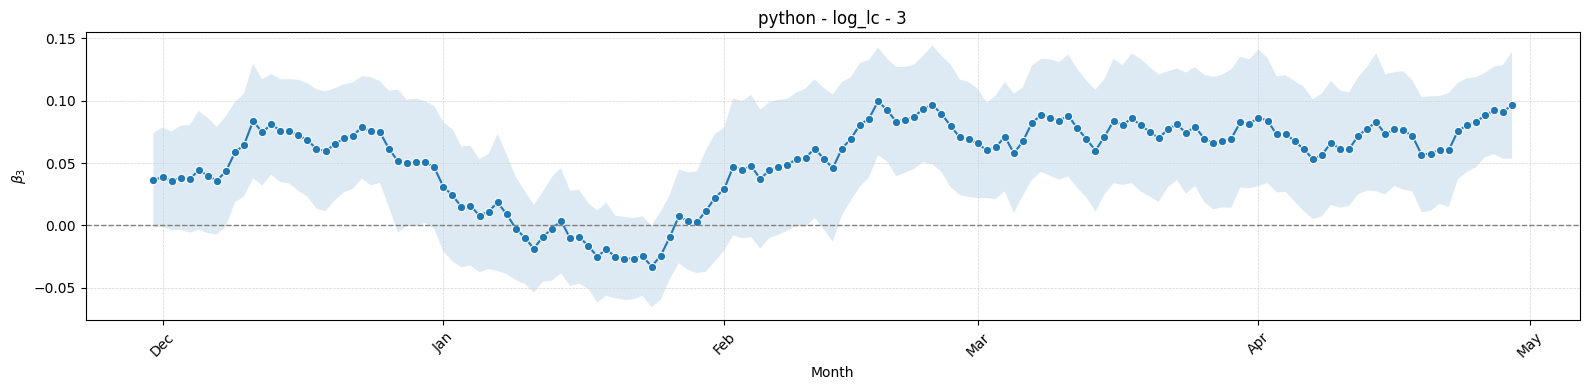

Processing: log_loc


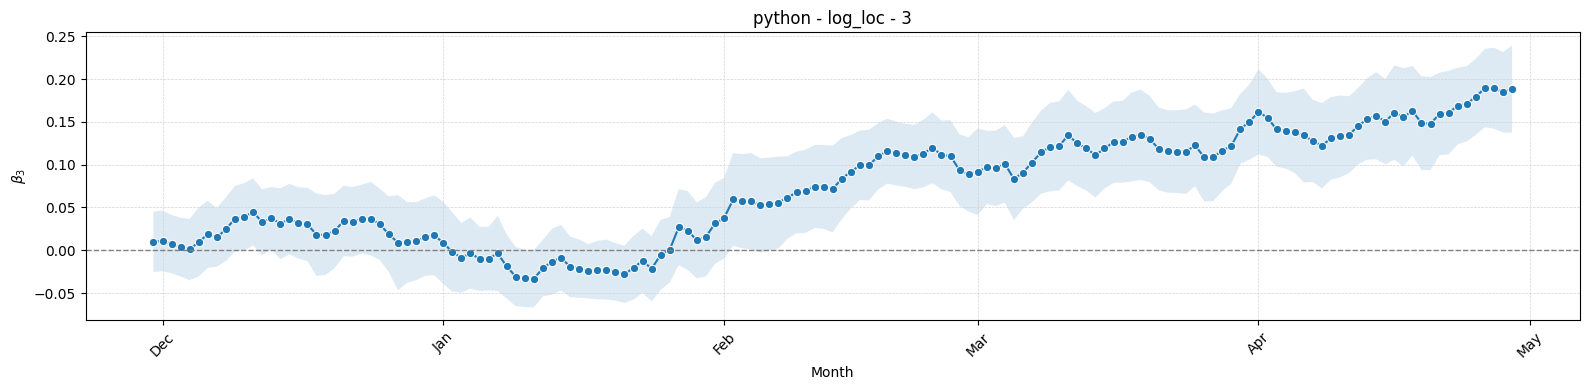

Processing: Medium


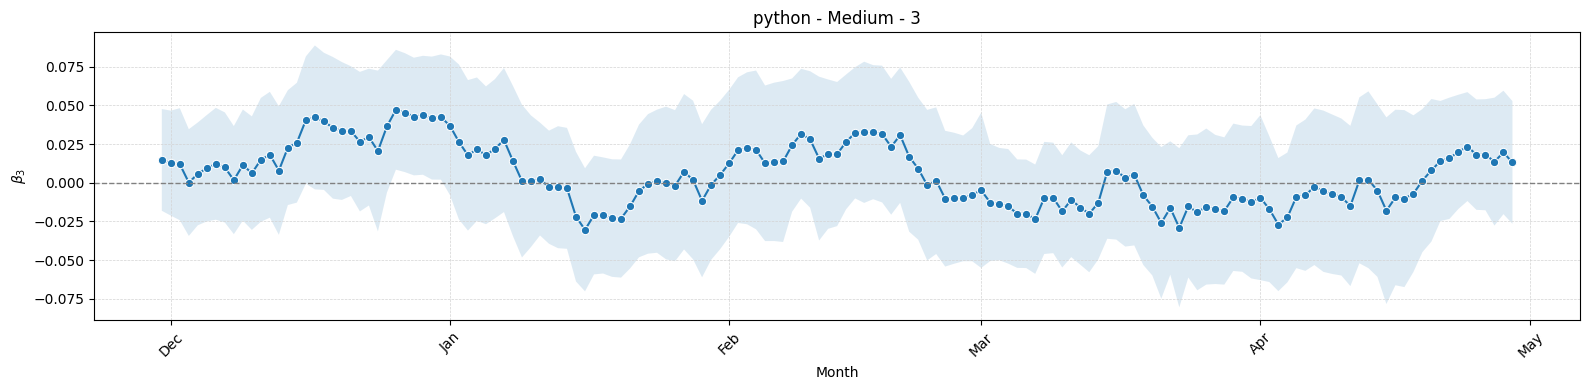

Processing: web
OwnerUserId
5432156.0     232
15157684.0    194
239219.0      184
10686620.0    182
15357136.0    174
             ... 
21975431.0      1
21975310.0      1
21975133.0      1
21975117.0      1
21974990.0      1
Length: 246826, dtype: int64


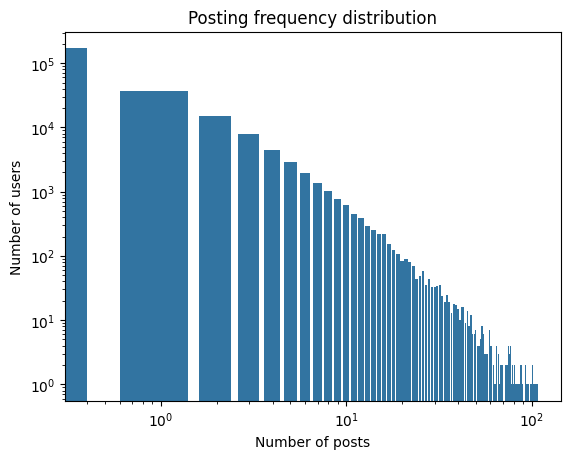

170616 77324 154646 77331
OwnerUserId
23499176.0    1
113.0         1
204.0         1
232.0         1
258.0         1
             ..
2505.0        1
2339.0        1
2132.0        1
1912.0        1
1463.0        1
Length: 170616, dtype: int64
Processing: log_lc


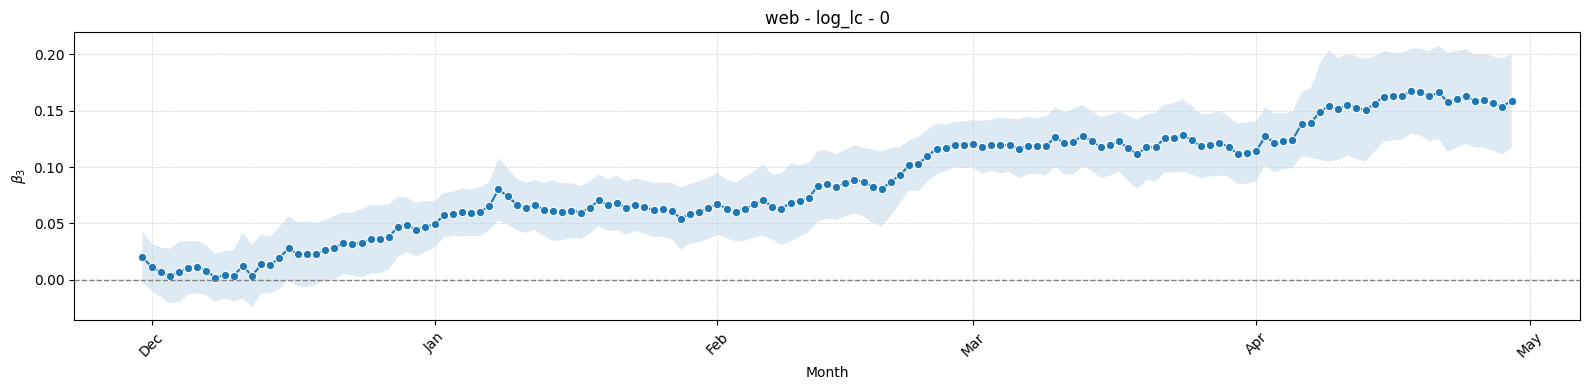

Processing: log_loc


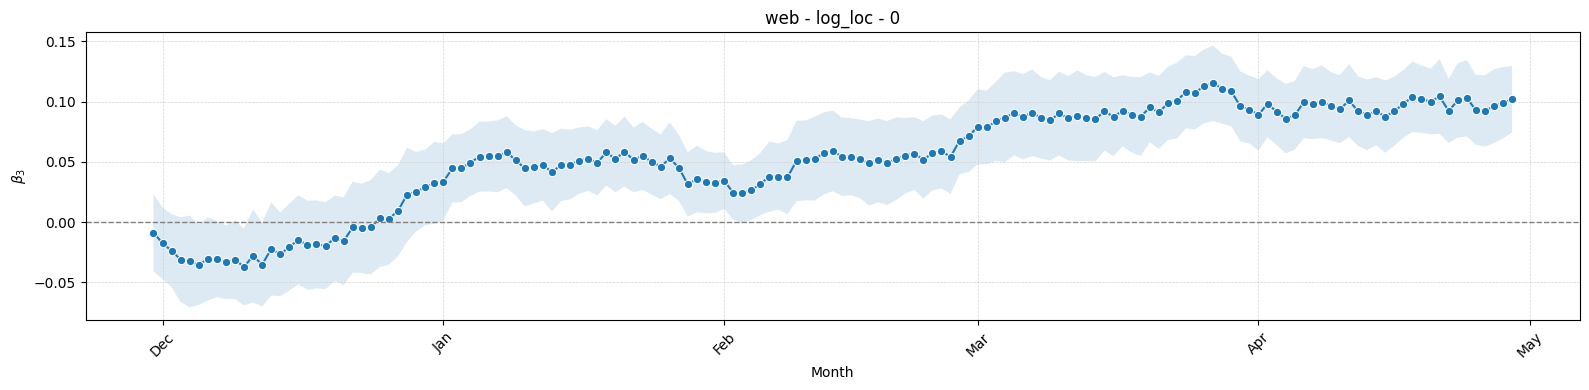

Processing: Medium


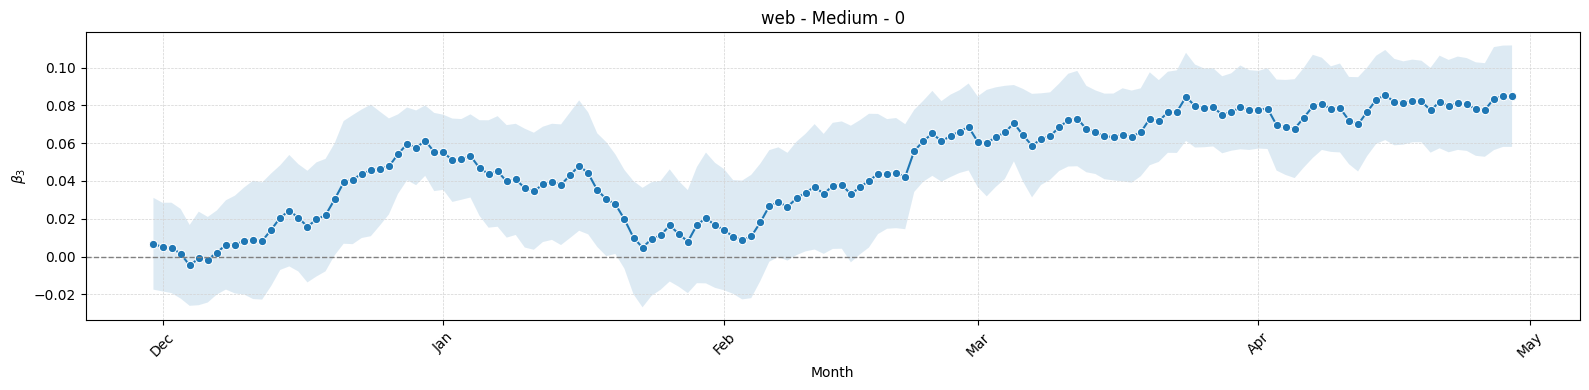

OwnerUserId
1103561.0     3
1103752.0     3
656963.0      3
437.0         3
1539019.0     3
             ..
21956160.0    2
21958597.0    2
21959067.0    2
21965597.0    2
298.0         2
Length: 38146, dtype: int64
Processing: log_lc


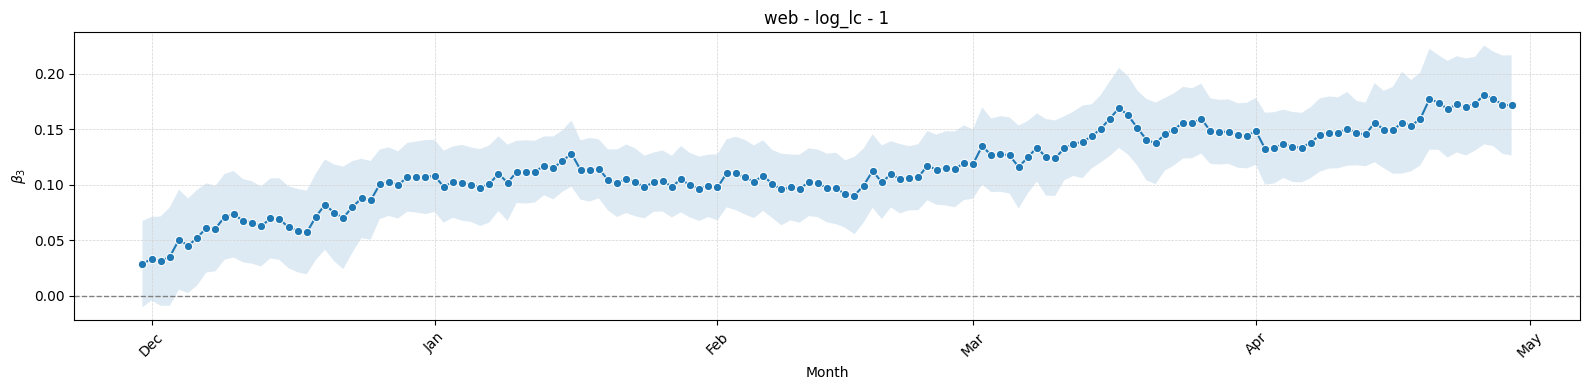

Processing: log_loc


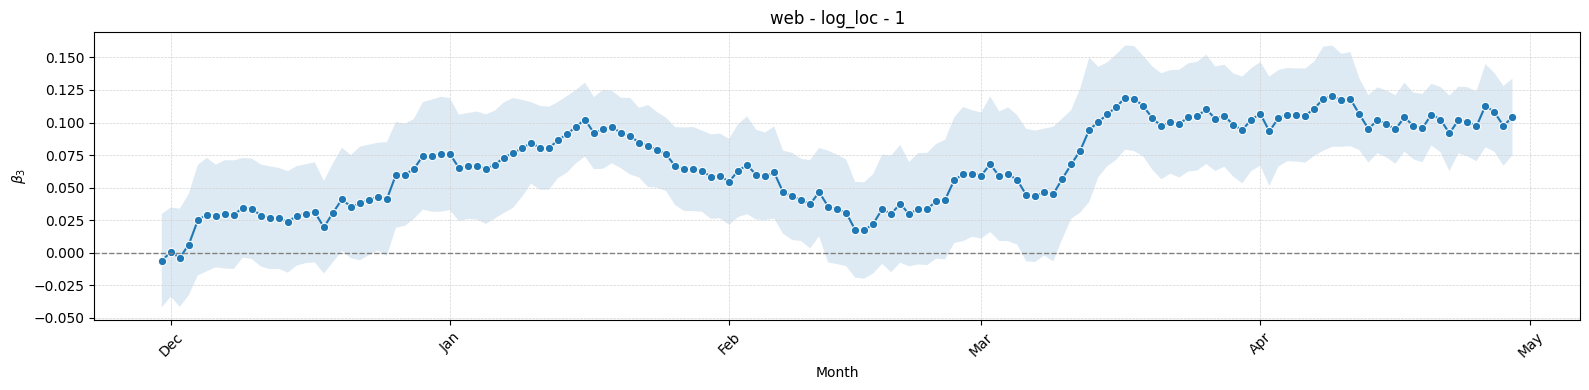

Processing: Medium


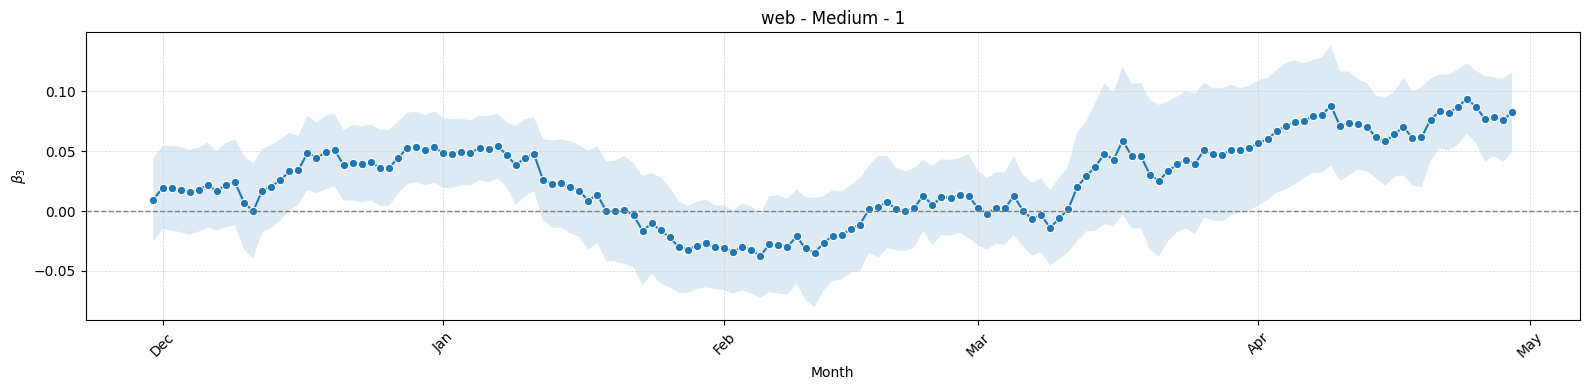

OwnerUserId
547768.0      11
482095.0      11
143269.0      11
434697.0      11
90800.0       11
              ..
21891746.0     3
21891432.0     3
21888581.0     3
21868486.0     3
21862872.0     3
Length: 34229, dtype: int64
Processing: log_lc


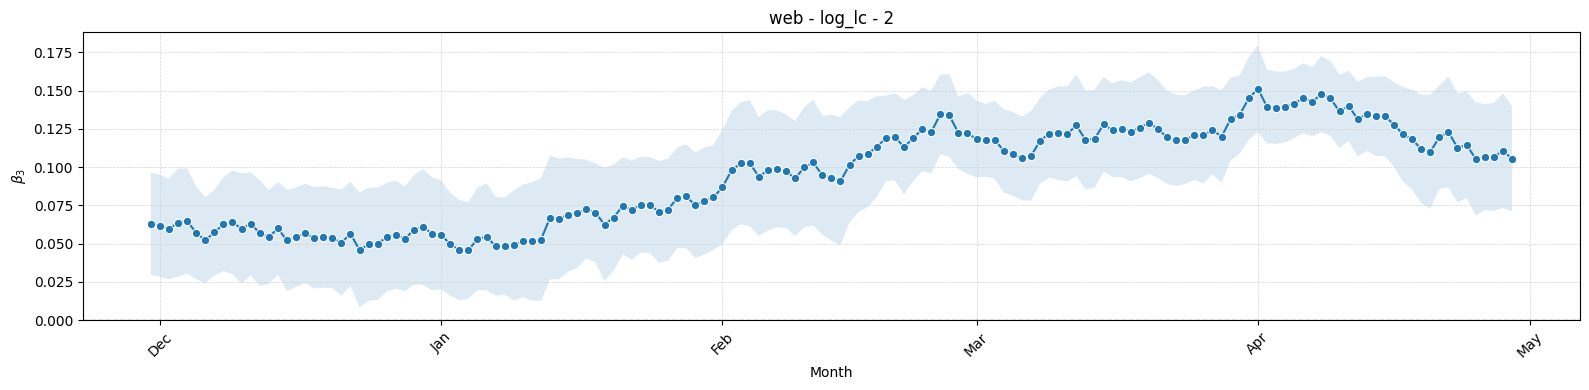

Processing: log_loc


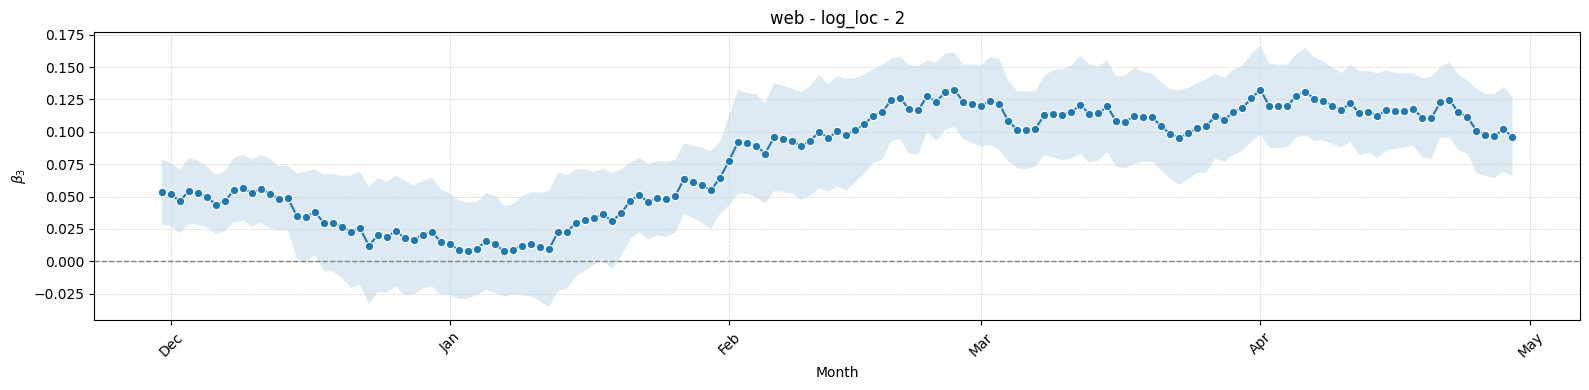

Processing: Medium


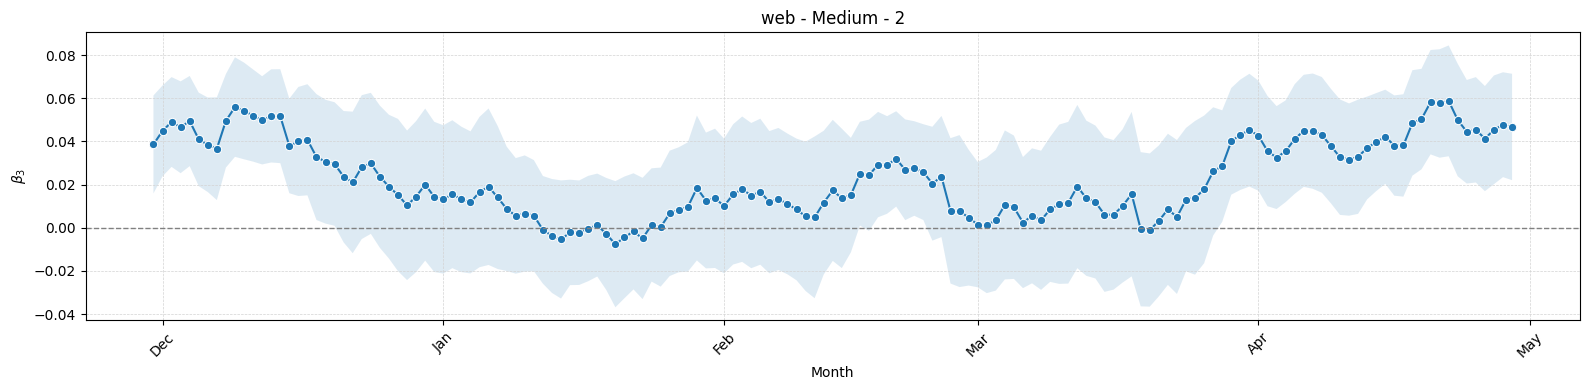

OwnerUserId
5432156.0     232
15157684.0    194
239219.0      184
10686620.0    182
15357136.0    174
             ... 
3574939.0      11
3633696.0      11
17710829.0     11
3686903.0      11
21189520.0     11
Length: 3835, dtype: int64
Processing: log_lc


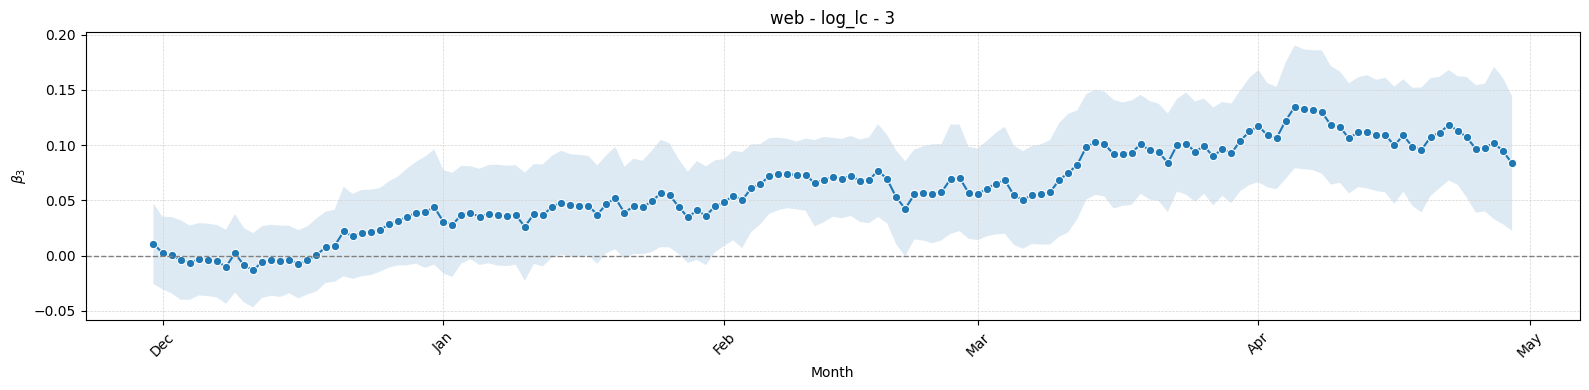

Processing: log_loc


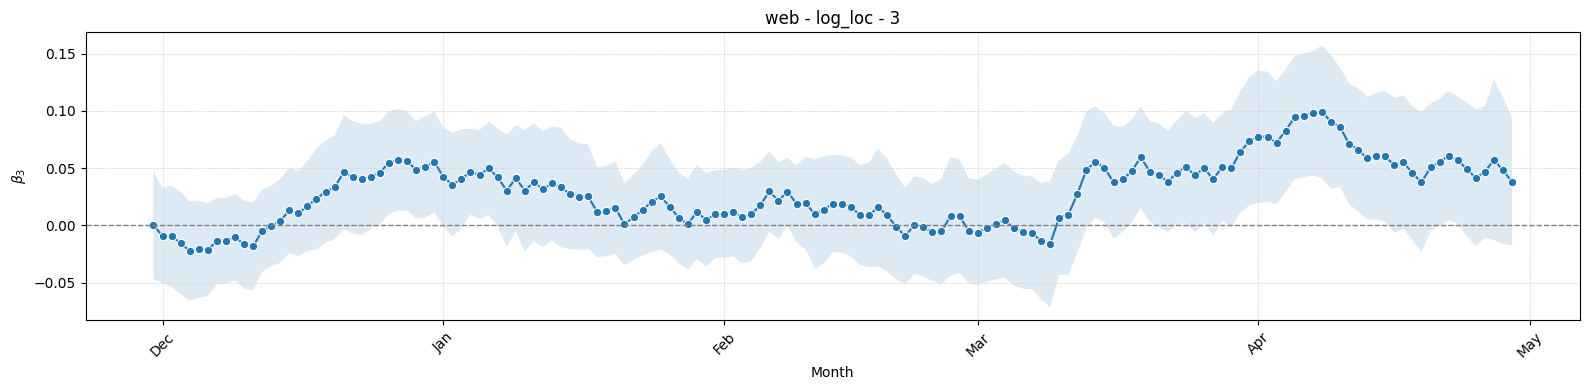

Processing: Medium


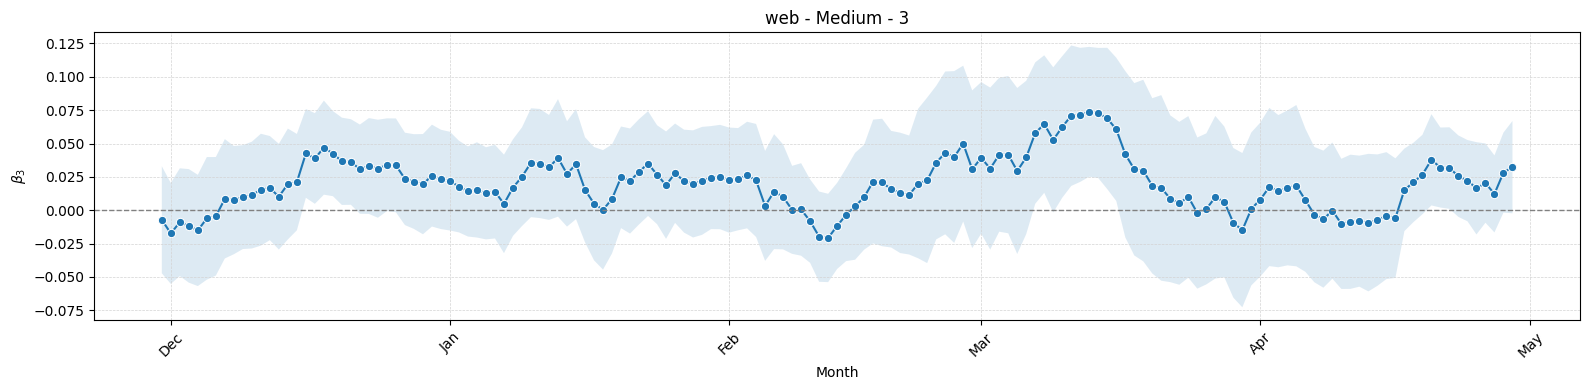

In [17]:
dfs = {'questions': questions, 'answers': answers} | tag_dfs
targets = ['log_lc', 'log_loc', 'Medium']
outcomes = {'questions': ['log_lc'], 'answers': ['log_lc'], 'java': targets, 'python': targets, 'web': targets}

for type in dfs:
    print(f'Processing: {type}')
    data = clean(dfs[type])
    up_df = join(dfs[type], users_df)

    counts = freq_dist(up_df)
    counts.describe()
    oneoff_events, sporadic_events, regular_events, power_events = groups(up_df, counts)
    print(len(oneoff_events), len(sporadic_events), len(regular_events), len(power_events))

    for i, events in enumerate([oneoff_events, sporadic_events, regular_events, power_events]):
        counts = events.groupby('OwnerUserId').size()
        counts_sorted = counts.sort_values(ascending=False)
        print(counts_sorted)

        daily = so.prepare_daily_data(events, outcomes[type])
        
        for outcome in outcomes[type]:
            print(f'Processing: {outcome}')
            res = regression(daily, outcome)
            so.plot_did(res, f'{type} - {outcome} - {i}', 'temp/temp.pdf')